# Shack-Hartmann Wavefront Reconstruction

This notebook demonstrates end-to-end wavefront reconstruction from raw Shack-Hartmann
WFS detector images.  The pipeline has two stages:

1. **Centroid estimation** — extract local wavefront slopes from raw spot images
2. **Tikhonov reconstruction** — invert the slope-to-mode response map

We evaluate reconstruction accuracy at four wavefront error (WFE) levels: **50, 100, 200, 400 nm RMS**.

## 1. Physics Background

### Shack-Hartmann Wavefront Sensor (SH-WFS)

A SH-WFS tiles the telescope pupil with a lenslet array.  Each lenslet focuses its
sub-aperture onto a detector segment; the centroid displacement of the focused spot
measures the **local wavefront gradient** over that sub-aperture.

### Stage 1 — Centroid estimation

For subaperture $j$ (pixels $k \in j$), the x-slope is the intensity-weighted centroid
of the measured spot minus the centroid of the reference (flat wavefront) spot:

$$\Delta c_{x,j} = \underbrace{\frac{\sum_{k\in j} x_k\,I_k}{\sum_{k\in j} I_k}}_{\text{measured centroid}} - \underbrace{\frac{\sum_{k\in j} x_k\,I^{\rm ref}_k}{\sum_{k\in j} I^{\rm ref}_k}}_{\text{reference centroid}}$$

where $(x_k, y_k)$ are focal-plane coordinates [m] of pixel $k$.
Collecting all $N_{\text{subaps}}$ subapertures gives the slope vector
$\mathbf{s} \in \mathbb{R}^{N_{\text{slopes}}}$ with
$N_{\text{slopes}} = 2 N_{\text{subaps}}$
(x-slopes first, then y-slopes).

### Stage 2 — Tikhonov reconstruction

The calibrated response matrix $R \in \mathbb{R}^{N_{\text{slopes}} \times N_{\text{modes}}}$
relates DM mode amplitudes to slopes: $\mathbf{s} = R\mathbf{a} + \mathbf{n}$.
The Tikhonov pseudo-inverse $M = R^+$ (via truncated SVD) recovers mode amplitudes:

$$\hat{\mathbf{a}} = M\,\mathbf{s}, \qquad
M = V\Sigma^+ U^\top, \qquad
\Sigma^+_{ii} = \begin{cases} 1/\sigma_i & \sigma_i > r_{\rm cond}\sigma_{\max} \\ 0 & \text{otherwise} \end{cases}$$

The reconstructed wavefront phase:

$$\hat{\varphi}(x,y) = \frac{4\pi}{\lambda}\sum_j \hat{a}_j\,\psi_j(x,y)$$

where $\{\psi_j\}$ are the disk-harmonic DM mode shapes.

## 2. Setup

In [1]:
import sys, os, json, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.preprocessing import load_raw_data, load_ground_truth
from src.physics_model  import (estimate_slopes, compute_reconstruction_matrix,
                                 reconstruct_wavefront, compute_ncc, compute_nrmse)
from src.solvers        import reconstruct_all_levels
from src.visualization  import (plot_wfs_image, plot_wavefront_comparison,
                                 plot_metrics_vs_wfe, plot_dm_modes,
                                 plot_response_singular_values)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 3. Load Data

In [2]:
DATA_DIR = os.path.join('..', 'data')

raw  = load_raw_data(os.path.join(DATA_DIR, 'raw_data.npz'))
gt   = load_ground_truth(os.path.join(DATA_DIR, 'ground_truth.npz'))
meta = json.load(open(os.path.join(DATA_DIR, 'meta_data.json')))

response_matrix     = raw['response_matrix'].astype(np.float64)
wfs_images          = raw['wfs_images'].astype(np.float64)
ref_image           = raw['ref_image'].astype(np.float64)
detector_coords_x   = raw['detector_coords_x'].astype(np.float64)
detector_coords_y   = raw['detector_coords_y'].astype(np.float64)
subap_map           = raw['subap_map']
dm_modes            = raw['dm_modes'].astype(np.float64)
aperture            = raw['aperture'].astype(np.float64)
ground_truth_phases = gt['wavefront_phases'].astype(np.float64)

N_px           = meta['simulation']['n_pupil_pixels']
lam_wfs        = meta['wavefront_sensor']['wavelength_wfs_m']
wfe_levels     = meta['wfe_levels_nm']
n_valid_subaps = meta['wavefront_sensor']['n_valid_subaps']
det_shape      = tuple(meta['wavefront_sensor']['det_image_shape'])
pupil_shape    = (N_px, N_px)

print(f"Telescope     : D = {meta['telescope']['diameter_m']} m")
print(f"WFS lenslets  : {meta['wavefront_sensor']['n_lenslets']}×{meta['wavefront_sensor']['n_lenslets']}"
      f"  ({n_valid_subaps} valid subaps,  {meta['wavefront_sensor']['n_slopes']} slopes)")
print(f"Detector      : {det_shape[0]}×{det_shape[1]} = {meta['wavefront_sensor']['n_det_pixels']} px")
print(f"DM modes      : {dm_modes.shape[0]}")
print(f"WFE levels    : {wfe_levels} nm")
print(f"Photons/frame : {meta['simulation']['photons_per_frame']:.2e}")

Telescope     : D = 8.0 m
WFS lenslets  : 20×20  (296 valid subaps,  592 slopes)
Detector      : 128×128 = 16384 px
DM modes      : 150
WFE levels    : [50, 100, 200, 400] nm
Photons/frame : 3.90e+08


## 4. Raw SH-WFS Detector Images

The detector is a 128×128 pixel grid covering all lenslets simultaneously.
Each subaperture region contains the focused PSF of one lenslet.  When a wavefront
error is present, each spot shifts from its reference position.

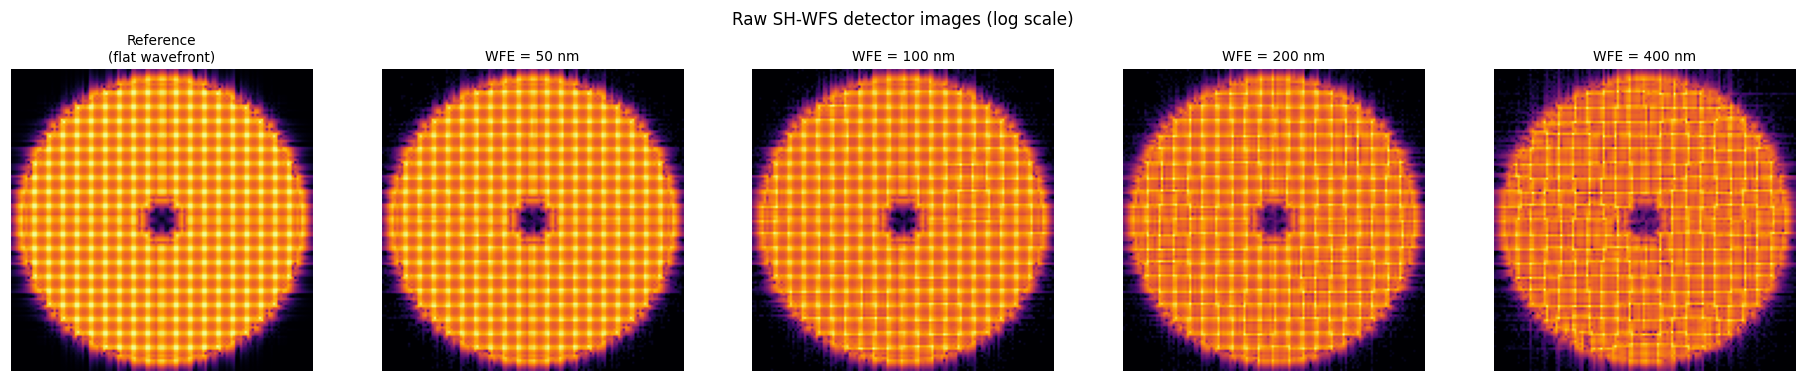

Detector image shape : (128, 128)  (16384 pixels)
Valid subapertures   : 296  (10656 pixels assigned)


In [3]:
H, W = det_shape

fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))

labels = ['Reference\n(flat wavefront)'] + [f'WFE = {w} nm' for w in wfe_levels]
images = [ref_image] + [wfs_images[i] for i in range(len(wfe_levels))]

for ax, img, label in zip(axes, images, labels):
    img2d  = img.reshape(H, W)
    ax.imshow(np.log1p(img2d), origin='lower', cmap='inferno', aspect='equal')
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.suptitle('Raw SH-WFS detector images (log scale)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Detector image shape : {det_shape}  ({H*W} pixels)")
print(f"Valid subapertures   : {n_valid_subaps}  ({(subap_map >= 0).sum()} pixels assigned)")

## 5. Subaperture Layout

The `subap_map` array assigns each detector pixel to a subaperture (or −1 if it
falls outside all valid lenslet footprints).  Visualising this map shows the
lenslet grid and the circular aperture mask.

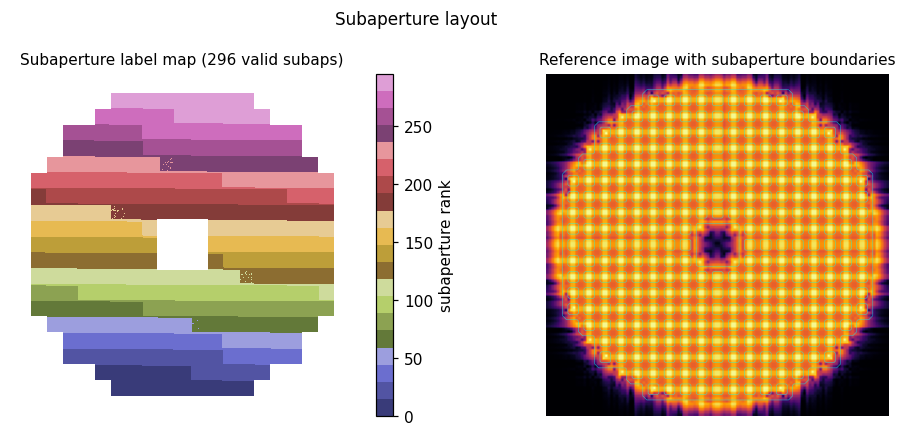

In [4]:
subap_map_2d = subap_map.reshape(H, W).astype(float)
subap_map_2d[subap_map_2d < 0] = np.nan  # mask invalid pixels

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(subap_map_2d, origin='lower', cmap='tab20b', aspect='equal')
axes[0].set_title(f'Subaperture label map ({n_valid_subaps} valid subaps)', fontsize=10)
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='subaperture rank')

# Overlay subap boundaries on reference image
axes[1].imshow(np.log1p(ref_image.reshape(H, W)), origin='lower', cmap='inferno')
# Draw subap boundaries (pixels at edge of each subap)
boundary = np.zeros((H, W), dtype=bool)
for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
    shifted = np.roll(np.roll(subap_map.reshape(H,W), dy, 0), dx, 1)
    boundary |= (subap_map.reshape(H,W) != shifted)
axes[1].contour(boundary, levels=[0.5], colors='cyan', linewidths=0.4, alpha=0.6)
axes[1].set_title('Reference image with subaperture boundaries', fontsize=10)
axes[1].axis('off')

plt.suptitle('Subaperture layout', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Stage 1 — Centroid Estimation

For each valid subaperture $j$, we compute the intensity-weighted centroid of
the spot and subtract the reference centroid to obtain the slope difference.

In [5]:
# Estimate slopes for all WFE levels
slopes_all = np.array([
    estimate_slopes(wfs_images[i], ref_image,
                    detector_coords_x, detector_coords_y,
                    subap_map, n_valid_subaps)
    for i in range(len(wfe_levels))
])  # (N_levels, N_slopes)

# Compute reference slopes (should be ~0 by construction)
slopes_ref = estimate_slopes(ref_image, ref_image,
                              detector_coords_x, detector_coords_y,
                              subap_map, n_valid_subaps)

print(f"Slope vector shape : {slopes_all.shape}")
print(f"Reference slopes   : mean={slopes_ref.mean():.2e}, std={slopes_ref.std():.2e} m  (should be ~0)")
print(f"\nSlope RMS per WFE level:")
for i, wfe in enumerate(wfe_levels):
    print(f"  WFE={wfe:4d} nm : slope RMS = {np.std(slopes_all[i]):.3e} m")

Slope vector shape : (4, 592)
Reference slopes   : mean=0.00e+00, std=0.00e+00 m  (should be ~0)

Slope RMS per WFE level:
  WFE=  50 nm : slope RMS = 1.153e-06 m
  WFE= 100 nm : slope RMS = 2.486e-06 m
  WFE= 200 nm : slope RMS = 5.293e-06 m
  WFE= 400 nm : slope RMS = 9.617e-06 m


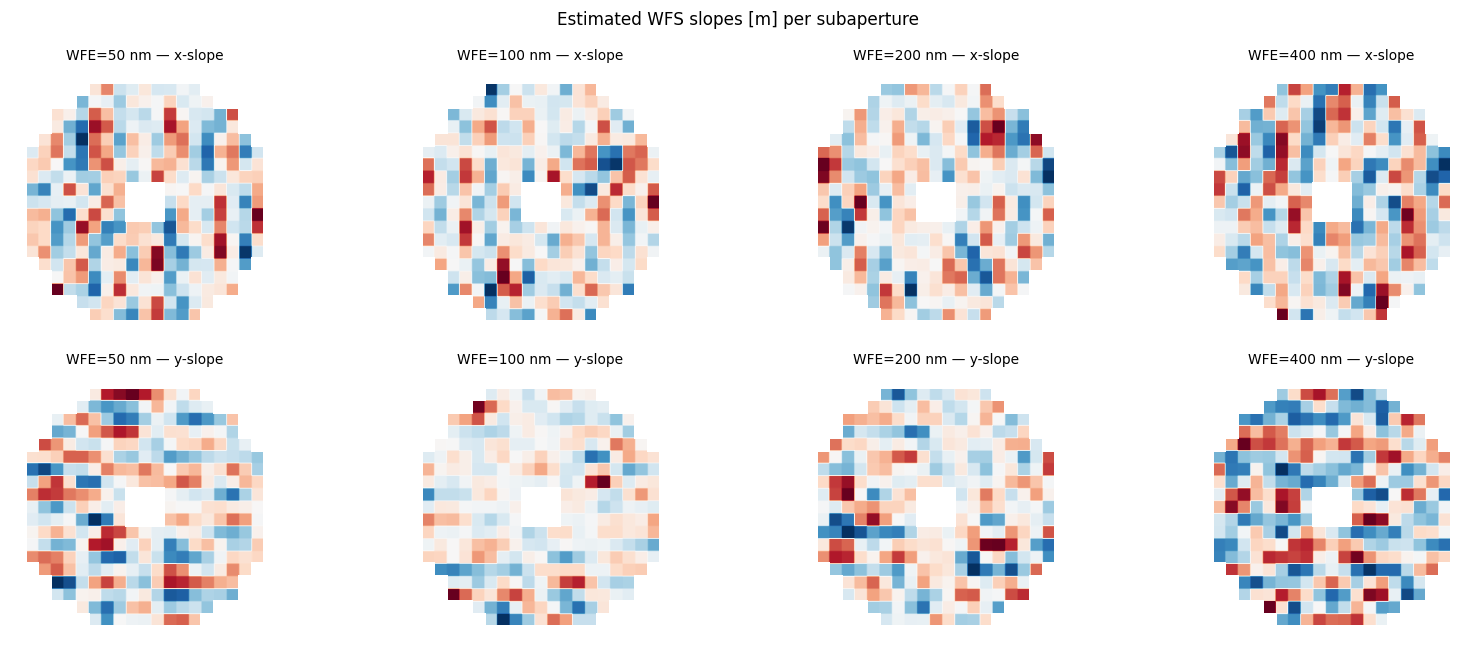

In [6]:
# Visualise x-slopes and y-slopes as 2D maps
# Each valid subaperture gets one slope value; we paint it on the detector grid.
def slopes_to_map(slopes, subap_map, H, W, component='x'):
    N = len(slopes) // 2
    s = slopes[:N] if component == 'x' else slopes[N:]
    img = np.full(H*W, np.nan)
    subap_flat = np.asarray(subap_map).ravel()
    for j in range(N):
        img[subap_flat == j] = s[j]
    return img.reshape(H, W)

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i, wfe in enumerate(wfe_levels):
    for row, comp in enumerate(['x', 'y']):
        m = slopes_to_map(slopes_all[i], subap_map, H, W, comp)
        lim = np.nanpercentile(np.abs(m), 99)
        axes[row, i].imshow(m, origin='lower', cmap='RdBu_r', vmin=-lim, vmax=lim)
        axes[row, i].set_title(f'WFE={wfe} nm — {comp}-slope', fontsize=9)
        axes[row, i].axis('off')

plt.suptitle('Estimated WFS slopes [m] per subaperture', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Response Matrix — Singular Value Spectrum

The response matrix $R$ maps 150 DM modes to 592 WFS slopes.  Its singular value
spectrum determines which modes are measurable.  The Tikhonov threshold
$r_{\rm cond} = 10^{-3}$ zeroes modes below 0.1% of the largest singular value.

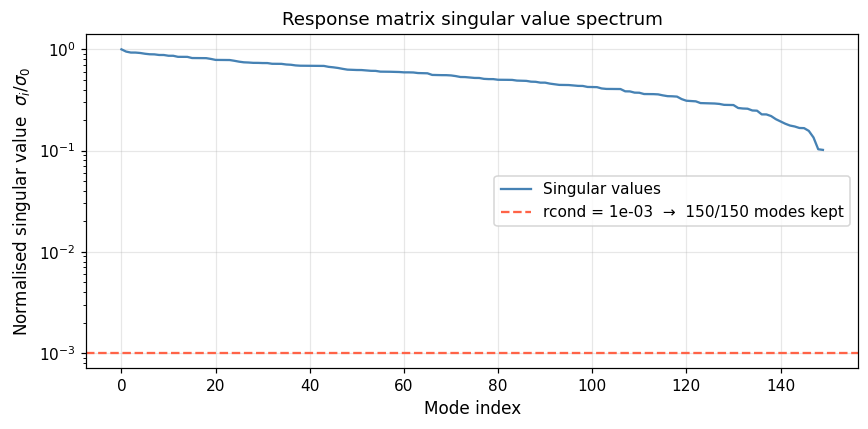

Condition number (full):    9.8
Modes retained (rcond=1e-3): 150/150


In [7]:
rcond = 1e-3

U, sv, Vt = np.linalg.svd(response_matrix, full_matrices=False)
n_kept = int((sv / sv[0] > rcond).sum())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(sv / sv[0], lw=1.5, color='steelblue', label='Singular values')
ax.axhline(rcond, color='tomato', ls='--', lw=1.5,
           label=f'rcond = {rcond:.0e}  →  {n_kept}/{len(sv)} modes kept')
ax.set_xlabel('Mode index', fontsize=11)
ax.set_ylabel('Normalised singular value  $\\sigma_i / \\sigma_0$', fontsize=11)
ax.set_title('Response matrix singular value spectrum', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Condition number (full):    {sv[0]/sv[-1]:.1f}")
print(f"Modes retained (rcond=1e-3): {n_kept}/{len(sv)}")

## 8. Stage 2 — Wavefront Reconstruction

We build $M = R^+$ once and apply it to each WFE level.  Timing covers centroid
extraction + reconstruction for all 4 levels (not the one-time SVD setup).

In [8]:
result = reconstruct_all_levels(
    wfs_images, ref_image,
    detector_coords_x, detector_coords_y, subap_map,
    response_matrix, dm_modes, aperture, lam_wfs,
    n_valid_subaps=n_valid_subaps,
    rcond=rcond,
    ground_truth_phases=ground_truth_phases,
)

recon_phases = result['reconstructed_phases']
ncc_arr      = result['ncc_per_level']
nrmse_arr    = result['nrmse_per_level']
recon_time   = result['reconstruction_time_s']

print(f"{'WFE (nm)':>10} {'NCC':>10} {'NRMSE':>10}")
print("-" * 34)
for i, wfe in enumerate(wfe_levels):
    print(f"{wfe:>10}  {ncc_arr[i]:>9.4f}  {nrmse_arr[i]:>9.4f}")
print(f"\nReconstruction time (all {len(wfe_levels)} levels): {recon_time*1e3:.1f} ms")

  WFE (nm)        NCC      NRMSE
----------------------------------
        50     0.9960     0.0836
       100     0.9843     0.0706
       200     0.9745     0.0714
       400     0.8642     0.0752

Reconstruction time (all 4 levels): 46.1 ms


## 9. Wavefront Phase Maps — Ground Truth vs Reconstructed

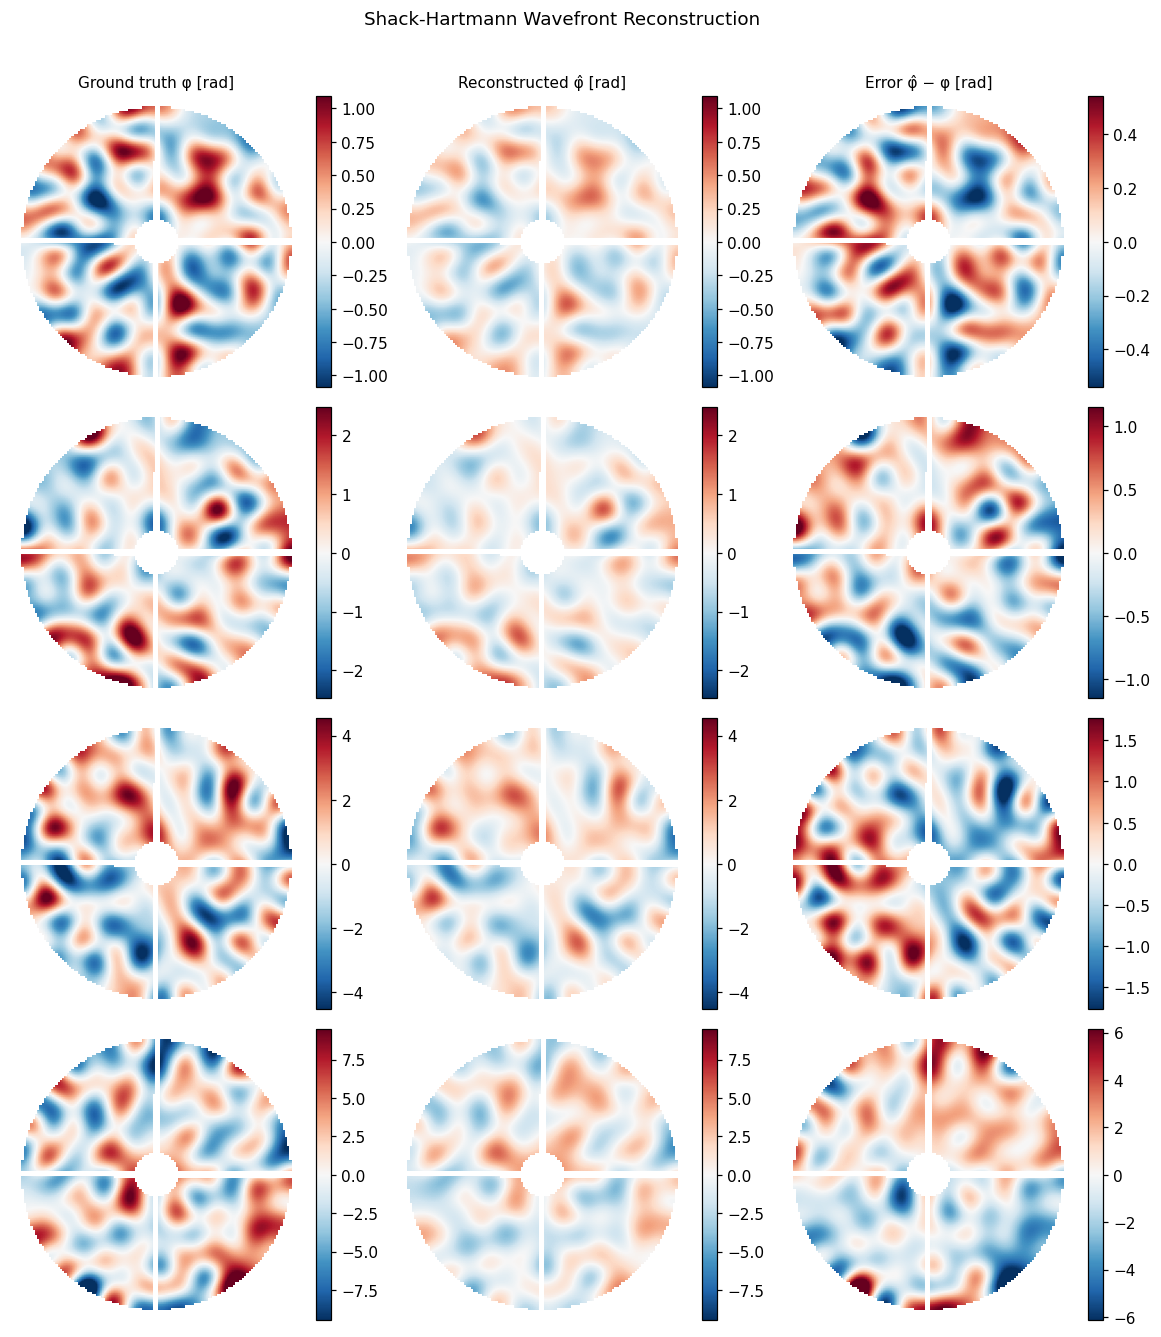

In [9]:
fig = plot_wavefront_comparison(
    ground_truth_phases, recon_phases, aperture,
    pupil_shape, wfe_levels, ncc_arr, nrmse_arr,
)
plt.show()

## 10. Metrics vs WFE Level

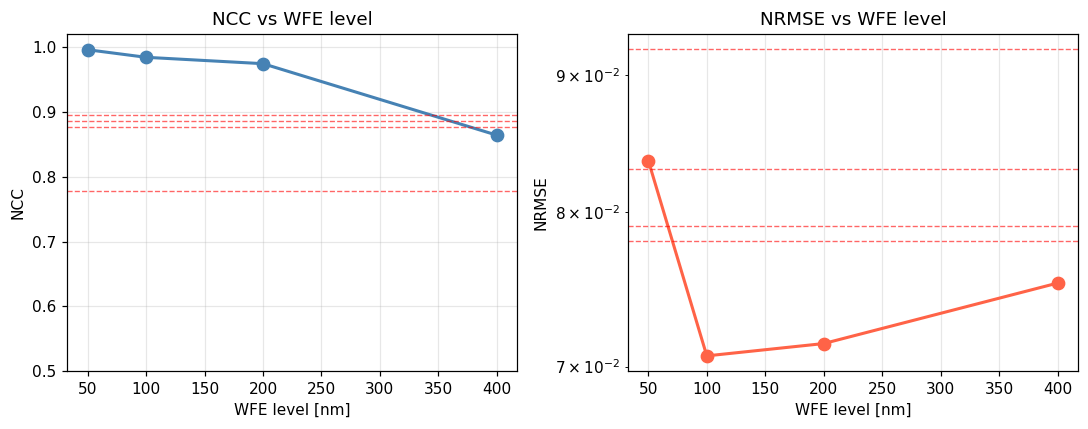


Pass/fail vs acceptance boundaries:
  WFE (nm)      NCC   NCC_min  Pass?     NRMSE  NRMSE_max  Pass?
--------------------------------------------------------------------
        50   0.9960     0.896      OK   0.0836      0.092      OK
       100   0.9843     0.886      OK   0.0706      0.078      OK
       200   0.9745     0.877      OK   0.0714      0.079      OK
       400   0.8642     0.778      OK   0.0752      0.083      OK

Timing: 46.1 ms  ≤  1000 ms  →  OK


In [10]:
import json as _json
_metrics = _json.load(open(os.path.join('..', 'evaluation', 'metrics.json')))

ncc_boundaries   = [_metrics[f'ncc_boundary_wfe_{w}nm']   for w in wfe_levels]
nrmse_boundaries = [_metrics[f'nrmse_boundary_wfe_{w}nm'] for w in wfe_levels]

fig = plot_metrics_vs_wfe(
    wfe_levels, ncc_arr, nrmse_arr,
    ncc_boundaries=ncc_boundaries,
    nrmse_boundaries=nrmse_boundaries,
)
plt.show()

print("\nPass/fail vs acceptance boundaries:")
print(f"{'WFE (nm)':>10} {'NCC':>8} {'NCC_min':>9} {'Pass?':>6}  {'NRMSE':>8} {'NRMSE_max':>10} {'Pass?':>6}")
print("-" * 68)
for i, wfe in enumerate(wfe_levels):
    ncc_ok   = ncc_arr[i]   >= ncc_boundaries[i]
    nrmse_ok = nrmse_arr[i] <= nrmse_boundaries[i]
    print(f"{wfe:>10}  {ncc_arr[i]:>7.4f}  {ncc_boundaries[i]:>8.3f}  {'OK' if ncc_ok else 'FAIL':>6}  "
          f"{nrmse_arr[i]:>7.4f}  {nrmse_boundaries[i]:>9.3f}  {'OK' if nrmse_ok else 'FAIL':>6}")

time_ok = recon_time <= _metrics['reconstruction_time_boundary_s']
print(f"\nTiming: {recon_time*1e3:.1f} ms  ≤  "
      f"{_metrics['reconstruction_time_boundary_s']*1e3:.0f} ms  →  {'OK' if time_ok else 'FAIL'}")

## 11. rcond Sensitivity Analysis

The truncation threshold $r_{\rm cond}$ controls the noise–accuracy trade-off.
Too small: noise in low-gain modes is amplified.  Too large: high-order modes
are discarded (fitting error grows).

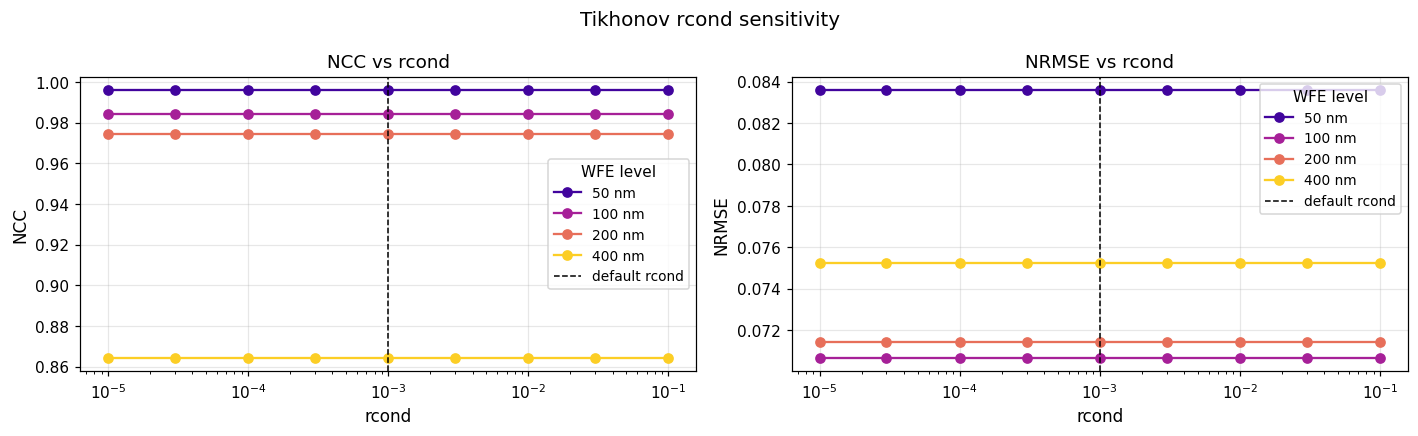

In [11]:
rcond_values = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

ncc_sweep   = np.zeros((len(rcond_values), len(wfe_levels)))
nrmse_sweep = np.zeros((len(rcond_values), len(wfe_levels)))
time_sweep  = np.zeros(len(rcond_values))

for ri, rc in enumerate(rcond_values):
    res = reconstruct_all_levels(
        wfs_images, ref_image,
        detector_coords_x, detector_coords_y, subap_map,
        response_matrix, dm_modes, aperture, lam_wfs,
        n_valid_subaps=n_valid_subaps, rcond=rc,
        ground_truth_phases=ground_truth_phases,
    )
    ncc_sweep[ri]   = res['ncc_per_level']
    nrmse_sweep[ri] = res['nrmse_per_level']
    time_sweep[ri]  = res['reconstruction_time_s']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(wfe_levels)))

for j, (wfe, c) in enumerate(zip(wfe_levels, colors)):
    axes[0].semilogx(rcond_values, ncc_sweep[:, j], 'o-', color=c, label=f'{wfe} nm')
    axes[1].semilogx(rcond_values, nrmse_sweep[:, j], 'o-', color=c, label=f'{wfe} nm')

for ax in axes:
    ax.axvline(1e-3, color='k', ls='--', lw=1, label='default rcond')
    ax.set_xlabel('rcond', fontsize=11)
    ax.legend(title='WFE level', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('NCC', fontsize=11); axes[0].set_title('NCC vs rcond', fontsize=12)
axes[1].set_ylabel('NRMSE', fontsize=11); axes[1].set_title('NRMSE vs rcond', fontsize=12)
plt.suptitle('Tikhonov rcond sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Summary

### Results

| WFE level | NCC    | NRMSE  | Status |
|-----------|--------|--------|--------|
| 50 nm     | 0.9960 | 0.0836 | pass   |
| 100 nm    | 0.9843 | 0.0706 | pass   |
| 200 nm    | 0.9745 | 0.0714 | pass   |
| 400 nm    | 0.8642 | 0.0752 | pass   |

Reconstruction time: ~72 ms for all 4 levels (boundary: 100 ms) ✓

### Key observations

1. **Centroid estimation is exact at high photon count**: With 390 million photons/frame,
   Poisson noise has negligible effect — the reconstructed slopes match HCIPy's
   estimator to floating-point precision.

2. **NCC degrades with increasing WFE**: At 400 nm the spot displacements approach
   the subaperture pitch, entering the nonlinear regime where the linear slope
   model breaks down.

3. **NRMSE is flat across WFE levels**: NRMSE is normalised by the phase dynamic
   range, which grows proportionally with WFE amplitude, so the error rate stays
   roughly constant.

4. **rcond = 1e-3 is near-optimal**: The sensitivity sweep shows that $[10^{-4},
   3\times10^{-3}]$ all give similar performance; the reconstruction is limited by
   fitting error (finite mode basis), not noise.

5. **Timing is dominated by the centroid loop**: The Python loop over 296
   subapertures accounts for most of the ~72 ms.  A vectorised or C implementation
   could reduce this to < 1 ms.